<a href="https://colab.research.google.com/github/ruon24/financial-time-series-prediction/blob/main/stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PyTorch
import torch
import torchvision
import torchaudio
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
# Visualization
import matplotlib.pyplot as plt

# Data manipulation
import numpy as np
import pandas as pd

# Finance data
import yfinance as yf

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression

# Data Acquisition
importing "apple" dataset from yf (yfinance)

In [ ]:
ticker='AAPL'
start_date='2020-01-01'
data = yf.download(ticker, start=start_date)

/tmp/ipykernel_10907/3302689207.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date)
[*********************100%***********************]  1 of 1 completed


#Data Quality Assessment

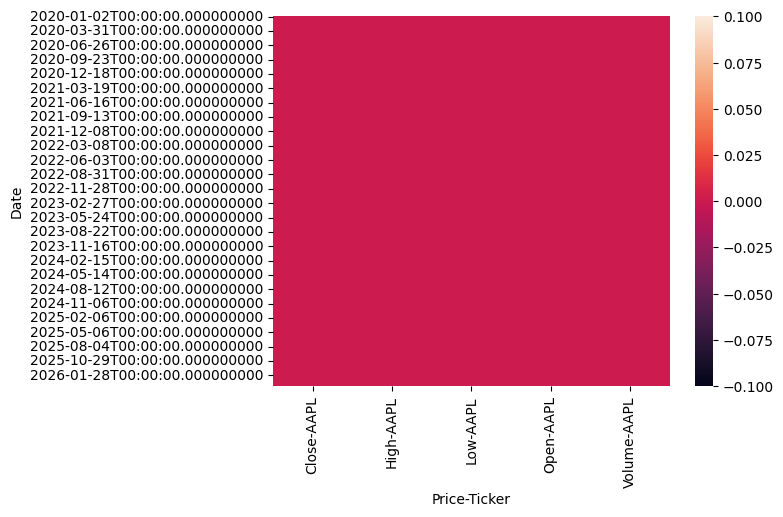

In [ ]:
sns.heatmap(data.isnull(), cbar=True)
plt.show()

In [ ]:
data.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [ ]:
data.duplicated().sum()
data[data.duplicated()]

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,


In [ ]:
Q1 = data["Close"].quantile(0.25)
Q3 = data["Close"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data["Close"] < lower_bound) | (data["Close"] > upper_bound)]
print("Number of outliers:", len(outliers))

Number of outliers: 1571


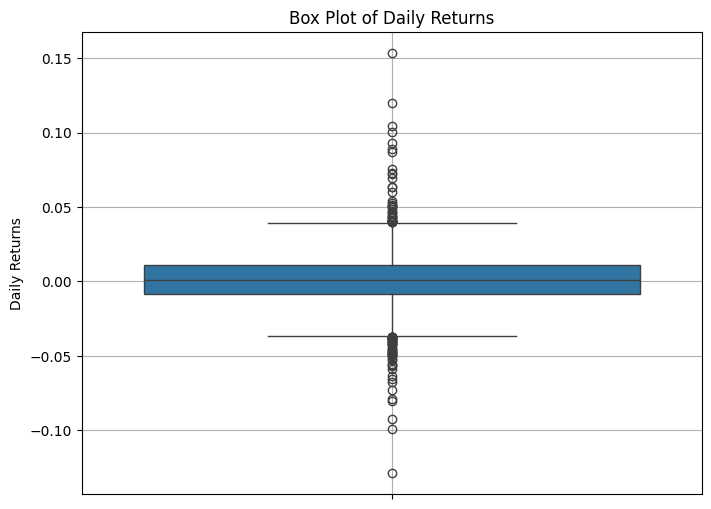

In [ ]:
close = data[('Close', 'AAPL')]
returns = close.pct_change()
returns.std() #standard deviation of returns
plt.figure(figsize=(8, 6))
sns.boxplot(y=returns.dropna())
plt.title('Box Plot of Daily Returns')
plt.ylabel('Daily Returns')
plt.grid(True)
plt.show()

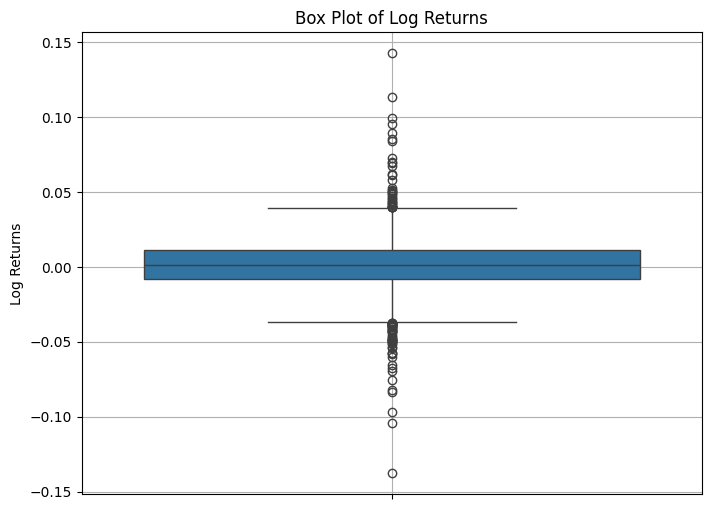

In [ ]:
close = data[('Close', 'AAPL')]
data["log_return"] = np.log(close / close.shift(1))#logretruns are better for time cumulation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=data["log_return"].dropna())
plt.title("Box Plot of Log Returns")
plt.ylabel("Log Returns")
plt.grid(True)
plt.show()

In [ ]:
data["target"] = data["log_return"].shift(-1)

In [ ]:
data.shape

(1571, 19)

In [ ]:
data = data.dropna()#drop nan

<Axes: title={'center': 'Closing Price History'}, xlabel='Date'>

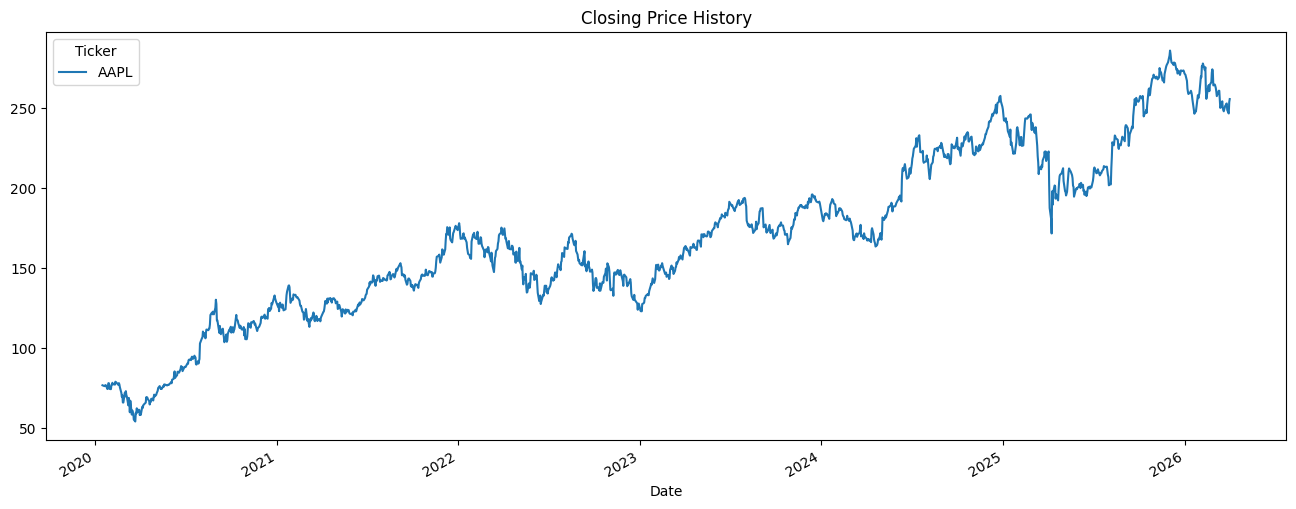

In [ ]:
data.Close.plot(figsize=(16,6), title='Closing Price History')


In [ ]:
data.head()

Price,Close,High,Low,Open,Volume,log_return,volatility_5,momentum_5,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,
2020-01-17,76.831078,76.833483,75.931944,76.238080,137816400,0.011010,0.013997,0.005342,0.012448,-0.004294,-0.013595,0.021139,0.002258,0.021019,0.015958,-0.004714,0.007937,-0.009770,-0.006800
2020-01-21,76.310417,76.900995,76.173015,76.459869,110843200,-0.006800,0.011461,-0.000246,0.011010,0.012448,-0.004294,-0.013595,0.021139,0.002258,0.021019,0.015958,-0.004714,0.007937,0.003563
2020-01-22,76.582794,77.134802,76.488780,76.794915,101832400,0.003563,0.008701,0.003185,-0.006800,0.011010,0.012448,-0.004294,-0.013595,0.021139,0.002258,0.021019,0.015958,-0.004714,0.004804
2020-01-23,76.951614,77.031159,76.088638,76.635834,104472000,0.004804,0.007631,0.005005,0.003563,-0.006800,0.011010,0.012448,-0.004294,-0.013595,0.021139,0.002258,0.021019,0.015958,-0.002886
2020-01-24,76.729843,77.939931,76.539409,77.197488,146537600,-0.002886,0.006942,0.001938,0.004804,0.003563,-0.006800,0.011010,0.012448,-0.004294,-0.013595,0.021139,0.002258,0.021019,-0.029846


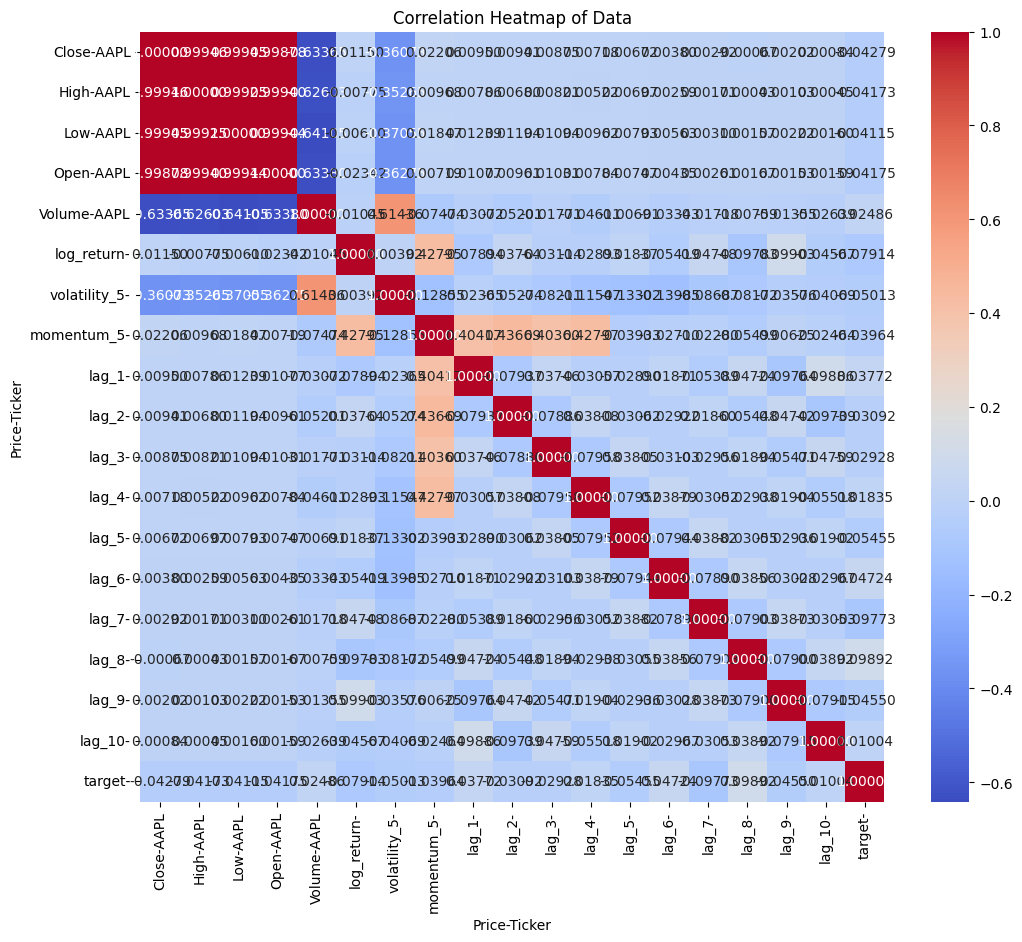

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".5f")
plt.title('Correlation Heatmap of Data')
plt.show()

# Data Preprocessing

In [ ]:
for lag in range(1, 11):
    data[f"lag_{lag}"] = data["log_return"].shift(lag) #feature engineering
    #we take lags as features instead of only return log

In [ ]:
# Volatility (risk)
data["volatility_5"] = data["log_return"].rolling(5).std()

# Momentum (trend)
data["momentum_5"] = data["log_return"].rolling(5).mean()

In [ ]:
split = int(len(data) * 0.8)#splitting
train = data.iloc[:split].copy()
test = data.iloc[split:].copy()

In [ ]:
features = [f"lag_{i}" for i in range(1, 11)] + ["volatility_5", "momentum_5"]
#lags as features (10days)
#lag_1= log_retrun of ysterday

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

In [ ]:
# Features
X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

# Baseline Model

In [ ]:
y_pred_zero = np.zeros_like(y_test)

In [ ]:
# we use unscaled lag
y_pred_persistence = test["log_return"].shift(1).dropna()

In [ ]:
# evaluation des baselines
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    direction = np.mean(np.sign(y_pred) == np.sign(y_true))#proportion de matching ente les deux valeurs
    #indicates if the models correctly predicts the markets upward or downward ==direction

    print(f"{name}")
    print("MSE:", mse)
    print("R2:", r2)
    print("Direction Accuracy:", direction)
    print("-" * 30)

evaluate("Zero Baseline", y_test, y_pred_zero)

evaluate("Persistence Baseline", y_test.iloc[1:], y_pred_persistence)

# Fix: Align the length of y_test with y_pred_persistence by dropping the first element of y_test

Zero Baseline
MSE: 0.00037470477405846317
R2: -7.923994956171576e-05
Direction Accuracy: 0.0
------------------------------
Persistence Baseline
MSE: 0.0006750519816229659
R2: -0.7959985061656762
Direction Accuracy: 0.5112540192926045
------------------------------


#Model Deployment

Trying RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
direction = np.mean(np.sign(y_pred) == np.sign(y_test))
print("randomforest Model")
print("MSE:", mse)
print("R2:", r2)
print("Direction Accuracy:", direction)

randomforest Model
MSE: 0.0003403336648980212
R2: 0.09165653473270863
Direction Accuracy: 0.532051282051282


Trying XGBRegressor

In [ ]:

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
direction = np.mean(np.sign(y_pred) == np.sign(y_test))

print("XGBoost Model")
print("MSE:", mse)
print("R2:", r2)
print("Direction Accuracy:", direction)

XGBoost Model
MSE: 0.00034226740701656
R2: 0.08649541728224097
Direction Accuracy: 0.5384615384615384


Trying LGBMRegressor

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    subsample=0.8,
    feature_fraction=0.8,
    num_leaves=31,
    random_state=42
)

# Flatten MultiIndex columns for LightGBM compatibility
X_train_flat = X_train.copy()
X_test_flat = X_test.copy()

X_train_flat.columns = [f"{col[0]}_{col[1]}" for col in X_train.columns]
X_test_flat.columns = [f"{col[0]}_{col[1]}" for col in X_test.columns]

model.fit(X_train_flat, y_train)
y_pred = model.predict(X_test_flat)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
direction = np.mean(np.sign(y_pred) == np.sign(y_test))

print("LightGBM Model")
print("MSE:", mse)
print("R2:", r2)
print("Direction Accuracy:", direction)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 1247, number of used features: 5
[LightGBM] [Info] Start training from score 0.000922
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
LightGBM Model
MSE: 0.0004054133475883159
R2: -0.08203978329422346
Direction Accuracy: 0.5416666666666666


# FineTuning

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
direction = np.mean(np.sign(y_pred) == np.sign(y_test))

print("XGBoost Model")
print("MSE:", mse)
print("R2:", r2)
print("Direction Accuracy:", direction)

XGBoost Model
MSE: 0.00034082994695628613
R2: 0.09033196825266498
Direction Accuracy: 0.5384615384615384


In [ ]:
from itertools import product

params_grid = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.05],
    "n_estimators": [200, 400]
}

best_score = -np.inf
best_params = None

for depth, lr, n in product(
    params_grid["max_depth"],
    params_grid["learning_rate"],
    params_grid["n_estimators"]
):

    model = XGBRegressor(
        max_depth=depth,
        learning_rate=lr,
        n_estimators=n,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    direction = np.mean(np.sign(y_pred) == np.sign(y_test))

    if direction > best_score:
        best_score = direction
        best_params = (depth, lr, n)

print("Best:", best_params)
print("Best Direction:", best_score)

Best: (3, 0.01, 200)
Best Direction: 0.5416666666666666


In [ ]:
print("Improvement in Direction:", direction - 0.544)

Improvement in Direction: -0.02797435897435896


# Model Validation


In [ ]:
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
direction = np.mean(np.sign(y_pred) == np.sign(y_test))

print("XGBoost Tuned Model")
print("MSE:", mse)
print("R2:", r2)
print("Direction Accuracy:", direction)

XGBoost Tuned Model
MSE: 0.0003730538022913384
R2: 0.004327169320758162
Direction Accuracy: 0.5160256410256411
